# 🌍 Exploring the World Through Data

## Lecture Overview

In this lecture, we shift from working with small, pre-structured datasets to **real-world global data**.

We will:

- explore multiple datasets about the world  
- build **reusable analysis functions**  
- learn how to **validate and trust data**  
- combine datasets to create new insights  
- visualize data both over time and **on a world map**  

---

## Key Idea

> Real-world data analysis is not about one dataset —  
> it is about combining multiple sources and extracting meaning.

---

## What makes this different from previous lectures?

So far, we have:

- created visualizations  
- explored single datasets  
- worked with clean, structured data  

Now we will:

- work with **multiple datasets**
- handle **data quality issues**
- build **reusable tools**
- connect data to **geography**

---

## Learning Objectives

By the end of this session, you should be able to:

- inspect and validate real-world datasets  
- create reusable functions for analysis and visualization  
- visualize global data on a **world map**  
- merge datasets using common keys  
- compute new variables (e.g. GDP per capita)  
- interpret and communicate insights  

---

# 🌐 What is Our World in Data (OWID)?

**Our World in Data (OWID)** is an open platform that provides:

- global datasets on topics such as:
  - population  
  - health  
  - economy  
  - environment  
- interactive visualizations  
- downloadable datasets for analysis  

-> [Our World in Data](https://ourworldindata.org/)

---

## Why OWID is useful

OWID is a powerful resource because:

- data is **well-structured and documented**
- datasets are **consistent across countries and years**
- it allows both:
  - quick exploration (via website)
  - deeper analysis (via downloaded data)

---

## Two ways to use OWID

### 1. Explore directly on the website

You can:

- interact with charts  
- filter countries  
- change variables  
- explore trends quickly  

-> This is useful for **idea generation**

---

### 2. Download and analyze the data

You can:

- download datasets as `.csv`
- load them into Python
- perform your own analysis
- create custom visualizations

-> This is what we will do in this lecture

---

## Key takeaway

> OWID allows us to move from **exploring data visually**  
> to **analyzing and building insights ourselves**

---

# Important Mindset

As we work through this lecture, always ask:

- What does this data represent?
- Can I trust this data?
- What might be missing or incorrect?
- What question am I trying to answer?

---


# Questions we will explore

- How has population changed over time?
- Which countries are the richest?
- Do richer countries live longer?
- How do global patterns differ across regions?

---

You can start by installing some additional libraries we will use today
- `geopandas` for working with geographic data
  - `folium` for creating interactive maps
  - `mapclassify` for classifying data for mapping

Run the following command, after which you can delete the cell:
```python
!pip install geopandas "folium>=0.12" mapclassify pycountry_convert
```

In [ ]:
!pip install geopandas "folium>=0.12" mapclassify pycountry_convert

# 1. Population Dataset

## Goal

We begin our analysis with the **population dataset**.

This will allow us to:

- understand the structure of real-world data  
- practice data inspection and validation  
- begin building reusable analysis steps  

---

## Important Practice

Before doing any analysis, we want to:

- give meaningful names to our data  
- understand what each column represents  

> Clear naming makes analysis easier, especially when working with multiple datasets.

---

# Load the Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

population_df = pd.read_csv("./data/population.csv")
population_df.head()

,country,country_code,year,population
0,Afghanistan,AFG,1950,7776180
1,Afghanistan,AFG,1951,7879343
2,Afghanistan,AFG,1952,7987784
3,Afghanistan,AFG,1953,8096703
4,Afghanistan,AFG,1954,8207954


### First Inspection

Before doing any analysis, we inspect the dataset.

In [2]:
population_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19388 entries, 0 to 19387
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   country       19388 non-null  str  
 1   country_code  18796 non-null  str  
 2   year          19388 non-null  int64
 3   population    19388 non-null  int64
dtypes: int64(2), str(2)
memory usage: 606.0 KB


In [3]:
population_df.describe()

,year,population
count,19388.00000,1.938800e+04
mean,1986.50000,1.471658e+08
std,21.36056,6.263607e+08
min,1950.00000,5.010000e+02
25%,1968.00000,3.128385e+05
50%,1986.50000,4.160666e+06
75%,2005.00000,2.016874e+07
max,2023.00000,8.091735e+09


### Initial Questions

- What is the time range of the dataset?
- How many countries are included per year?
- Are there missing values?
- Do the values look reasonable?

## Data Inspection

### Missing Values

First, we check for missing values in the dataset.

#### Interpretation

- Are there missing values?
- If yes, how many?
- In which columns?

#### Possible strategies

- remove missing values  
- fill them (if appropriate)  
- leave them but be aware  

In [4]:
population_df.isna().sum()

country           0
country_code    592
year              0
population        0
dtype: int64

In [5]:
population_df[population_df.isna().any(axis=1)]['country'].unique()

<StringArray>
[                                              'Americas (UN)',
                     'Land-locked developing countries (LLDC)',
                                   'Least developed countries',
                                      'Less developed regions',
                     'Less developed regions, excluding China',
 'Less developed regions, excluding least developed countries',
                                      'More developed regions',
                       'Small island developing states (SIDS)']
Length: 8, dtype: str

Very interesting! OWID provides aggregate data as well, where it combines countries into regions (e.g. "Americas (UN)", "Less developed regions", etc.). These aggregate rows have missing values for the `country_code` column, which is expected since they do not represent individual countries.

```
Tip: OWID also provides continent level aggregates, which can be useful for regional analysis.
```

### Minimum and Maximum Values

Do the values in the `population` column look reasonable?

In [6]:
population_df["population"].min(), population_df["population"].max()

(np.int64(501), np.int64(8091734933))

### Time Range

What is the time range of the dataset?

In [7]:
population_df["year"].min(), population_df["year"].max()

(np.int64(1950), np.int64(2023))

## Question

How has the **total world population** changed over time?

In [8]:
global_population = (
    population_df
    .groupby("year")["population"]
    .sum()
    .reset_index()
)

global_population.head()

,year,population
0,1950,18221925737
1,1951,18553467337
2,1952,18910393240
3,1953,19288727200
4,1954,19680934293


In [3]:
from functions import remove_aggregate_rows
import pandas as pd
population_df = pd.read_csv('./data/population.csv')
population_df = remove_aggregate_rows(population_df)
global_population = (
    population_df
    .groupby("year")["population"]
    .agg('sum')
    .reset_index()
)

global_population.tail()

,year,population
69,2019,7811295099
70,2020,7887002573
71,2021,7954449776
72,2022,8021408467
73,2023,8091736392


### Task

- visualize the total world population over time using a line plot

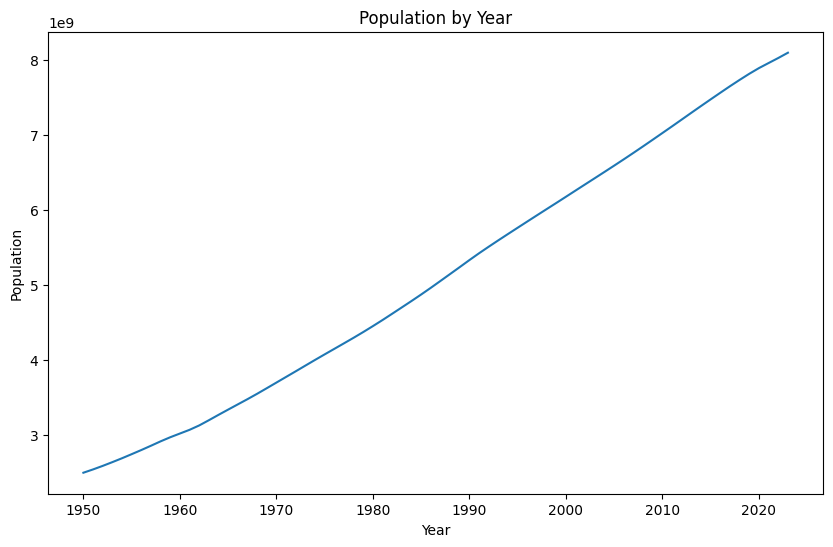

In [11]:
# Your code goes here

fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(x='year', y='population', data=global_population, ax=ax)
ax.set_title('Population by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Population')
plt.show()

###  Improve readability

Population numbers are very large, which makes them hard to interpret.

We can convert them to **billions** for better readability.

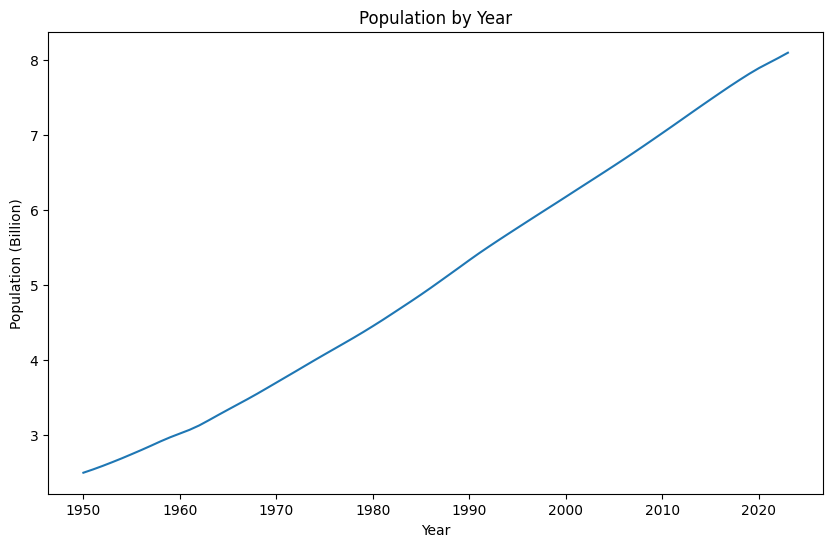

In [15]:
# Your code goes here

global_population['population_billions'] = global_population['population'] / 1e9

fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(x='year', y='population_billions', data=global_population, ax=ax)
ax.set_title('Population by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Population (Billion)')
plt.show()

- Does the growth appear linear or exponential?
- Are there periods of faster or slower growth?

In [17]:
global_population["growth_rate"] = (global_population["population"].pct_change() * 100)

global_population.head()

,year,population,population_billions,growth_rate
0,1950,2493094925,2.493095,NaN
1,1951,2536929208,2.536929,1.758228
2,1952,2584088425,2.584088,1.858909
3,1953,2634108211,2.634108,1.935684
4,1954,2685896857,2.685897,1.966079


### Task
- visualize the growth rate of the world population over time using a line plot
- use seaborn's `lineplot`

<Axes: xlabel='year', ylabel='growth_rate'>

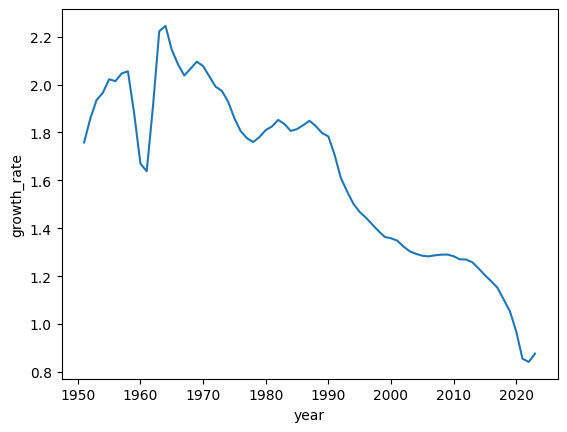

In [18]:
# Your code goes here
fig, ax = plt.subplots()
sns.lineplot(data=global_population, x='year', y='growth_rate')

# Discussion

- Is the population growth rate increasing or decreasing?
- When was growth the fastest?
- Is global population growth slowing down?
- What might explain changes over time?

---

# Key Insight

> Even if total population keeps increasing,  
> the **growth rate can decrease over time**.

This is an important distinction between:

- absolute growth  
- relative growth  

In [21]:
from functions import add_continent_column

population_df = add_continent_column(population_df)
population_df.head()

,country,country_code,year,population,continent
0,Afghanistan,AFG,1950,7776180,Asia
1,Afghanistan,AFG,1951,7879343,Asia
2,Afghanistan,AFG,1952,7987784,Asia
3,Afghanistan,AFG,1953,8096703,Asia
4,Afghanistan,AFG,1954,8207954,Asia


In [22]:
continent_population = (
    population_df
    .groupby(["year", "continent"])["population"]
    .sum().reset_index()
)

continent_population['population_million'] = continent_population['population'] / 1e6
continent_population.head()

,year,continent,population,population_million
0,1950,Africa,225270578,225.270578
1,1950,Asia,1368075676,1368.075676
2,1950,Europe,548089325,548.089325
3,1950,North America,222818942,222.818942
4,1950,Oceania,12582453,12.582453


### Task
- visualize the world population by continent over time using a line plot
- use seaborn's `lineplot`

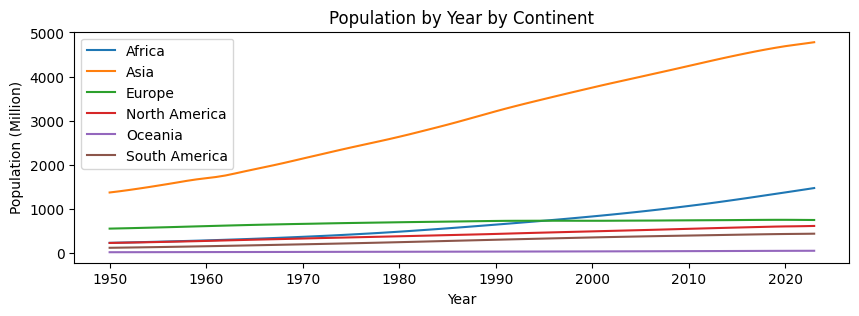

In [24]:
# Your code goes here
fig, ax = plt.subplots(figsize=(10,3))
sns.lineplot(x='year', y='population_million', hue='continent', data=continent_population, ax=ax)
ax.set_title('Population by Year by Continent')
ax.set_xlabel('Year')
ax.set_ylabel('Population (Million)')
ax.legend()
plt.show()

In [25]:
continent_population = continent_population.sort_values(["continent", "year"])

continent_population["growth_rate"] = (
    continent_population
    .groupby("continent")["population_million"]
    .pct_change()
    * 100
)

continent_population.head()

,year,continent,population,population_million,growth_rate
0,1950,Africa,225270578,225.270578,NaN
6,1951,Africa,230013530,230.013530,2.105447
12,1952,Africa,234955147,234.955147,2.148403
18,1953,Africa,240056693,240.056693,2.171285
24,1954,Africa,245330556,245.330556,2.196924


### Task
- create a line plot of continental population growth over time
- use seaborn's `lineplot`

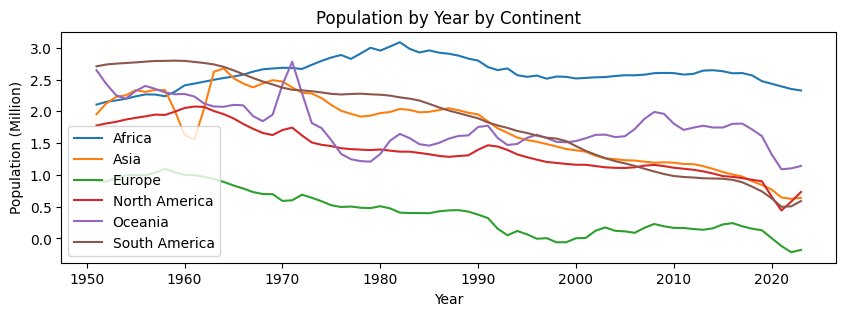

In [26]:
# Your code goes here

# Your code goes here
fig, ax = plt.subplots(figsize=(10,3))
sns.lineplot(x='year', y='growth_rate', hue='continent', data=continent_population, ax=ax)
ax.set_title('Population by Year by Continent')
ax.set_xlabel('Year')
ax.set_ylabel('Population (Million)')
ax.legend()
plt.show()

In [31]:
decade_country = population_df.copy()
decade_country['decade'] = decade_country['year'] // 10

decade_country.head(11)

,country,country_code,year,population,continent,decade
0,Afghanistan,AFG,1950,7776180,Asia,195
1,Afghanistan,AFG,1951,7879343,Asia,195
2,Afghanistan,AFG,1952,7987784,Asia,195
3,Afghanistan,AFG,1953,8096703,Asia,195
4,Afghanistan,AFG,1954,8207954,Asia,195
5,Afghanistan,AFG,1955,8326981,Asia,195
6,Afghanistan,AFG,1956,8454303,Asia,195
7,Afghanistan,AFG,1957,8588340,Asia,195
8,Afghanistan,AFG,1958,8723412,Asia,195
9,Afghanistan,AFG,1959,8869270,Asia,195


In [38]:
pop_avg_decade = decade_country.groupby(['decade', 'continent', 'country'])['population'].mean().reset_index()
pop_avg_decade.head()

,decade,continent,country,population
0,195,Africa,Algeria,10118691.9
1,195,Africa,Angola,4820314.6
2,195,Africa,Benin,2350623.0
3,195,Africa,Botswana,458953.8
4,195,Africa,Burkina Faso,4449950.9


In [50]:
pop_avg_decade.sort_values(by='population', ascending=False)#['country'].unique()[:10]

,decade,continent,country,population
1702,202,Asia,China,1.425077e+09
1707,202,Asia,India,1.420079e+09
1468,201,Asia,China,1.390336e+09
1473,201,Asia,India,1.318680e+09
1234,200,Asia,China,1.306203e+09
...,...,...,...,...
857,198,Europe,Vatican,7.443000e+02
1091,199,Europe,Vatican,7.200000e+02
1325,200,Europe,Vatican,6.690000e+02
1559,201,Europe,Vatican,5.858000e+02


In [56]:
df_filtered.sort_values(by='population', ascending=False)['country'].unique()[:10]

<StringArray>
[        'Russia',        'Germany', 'United Kingdom',         'France',
          'Italy',        'Ukraine',          'Spain',         'Poland',
        'Romania',    'Netherlands']
Length: 10, dtype: str

<Axes: xlabel='decade', ylabel='population'>

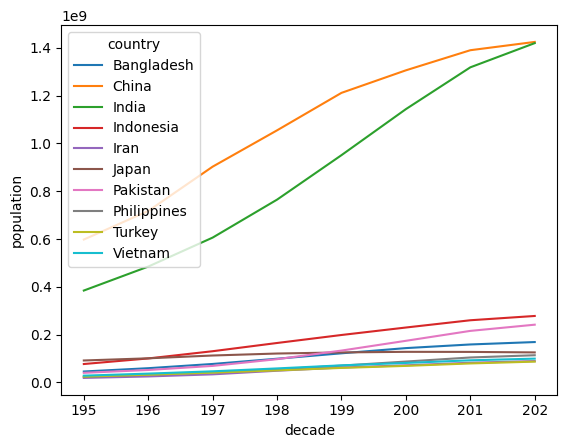

In [58]:

df_filtered = pop_avg_decade[pop_avg_decade['continent'] == 'Asia']

top_countries = df_filtered.sort_values(by='population', ascending=False)['country'].unique()[:10]

df_filtered = df_filtered[df_filtered['country'].isin(top_countries)]

sns.lineplot(data=df_filtered, x='decade', y='population', hue='country', legend=True)

# Discussion

- Which continents have the largest populations?
- Which continents are growing the fastest?
- Is growth slowing down globally or only in certain regions?

# 2. Geographic Visualization with GeoPandas

## Goal

So far, we have looked at:

- global trends  
- continent-level trends  

Now we introduce a new perspective:

> Where is the population located?

To answer this, we visualize data on a **world map**.

---

# What is GeoPandas?

GeoPandas extends pandas to work with **geographic data**.

It allows us to:

- load map data (countries, regions)
- merge it with our dataset
- visualize values on a map

---

# Step 1 — Load World Map Data

We load a dataset containing country geometries.

In [59]:
import geopandas as gpd

gdf = gpd.read_file(
    "https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_110m_admin_0_countries.geojson"
)

gdf.head()

,scalerank,labelrank,sovereignt,sov_a3,adm0_dif,level,type,admin,adm0_a3,geou_dif,...,region_un,subregion,region_wb,name_len,long_len,abbrev_len,tiny,homepart,featureclass,geometry
0,1,3,Afghanistan,AFG,0,2,Sovereign country,Afghanistan,AFG,0,...,Asia,Southern Asia,South Asia,11,11,4,-99,1,Admin-0 country,"POLYGON ((61.21082 35.65007, 62.23065 35.27066..."
1,1,3,Angola,AGO,0,2,Sovereign country,Angola,AGO,0,...,Africa,Middle Africa,Sub-Saharan Africa,6,6,4,-99,1,Admin-0 country,"MULTIPOLYGON (((16.32653 -5.87747, 16.57318 -6..."
2,1,6,Albania,ALB,0,2,Sovereign country,Albania,ALB,0,...,Europe,Southern Europe,Europe & Central Asia,7,7,4,-99,1,Admin-0 country,"POLYGON ((20.59025 41.8554, 20.46318 41.51509,..."
3,1,4,United Arab Emirates,ARE,0,2,Sovereign country,United Arab Emirates,ARE,0,...,Asia,Western Asia,Middle East & North Africa,20,20,6,-99,1,Admin-0 country,"POLYGON ((51.57952 24.2455, 51.75744 24.29407,..."
4,1,2,Argentina,ARG,0,2,Sovereign country,Argentina,ARG,0,...,Americas,South America,Latin America & Caribbean,9,9,4,-99,1,Admin-0 country,"MULTIPOLYGON (((-65.5 -55.2, -66.45 -55.25, -6..."


In [60]:
gdf.columns

Index(['scalerank', 'labelrank', 'sovereignt', 'sov_a3', 'adm0_dif', 'level',
       'type', 'admin', 'adm0_a3', 'geou_dif', 'geounit', 'gu_a3', 'su_dif',
       'subunit', 'su_a3', 'brk_diff', 'name', 'name_long', 'brk_a3',
       'brk_name', 'brk_group', 'abbrev', 'postal', 'formal_en', 'formal_fr',
       'note_adm0', 'note_brk', 'name_sort', 'name_alt', 'mapcolor7',
       'mapcolor8', 'mapcolor9', 'mapcolor13', 'pop_est', 'gdp_md_est',
       'pop_year', 'lastcensus', 'gdp_year', 'economy', 'income_grp',
       'wikipedia', 'fips_10', 'iso_a2', 'iso_a3', 'iso_n3', 'un_a3', 'wb_a2',
       'wb_a3', 'woe_id', 'adm0_a3_is', 'adm0_a3_us', 'adm0_a3_un',
       'adm0_a3_wb', 'continent', 'region_un', 'subregion', 'region_wb',
       'name_len', 'long_len', 'abbrev_len', 'tiny', 'homepart',
       'featureclass', 'geometry'],
      dtype='str')

We start with a simple map.

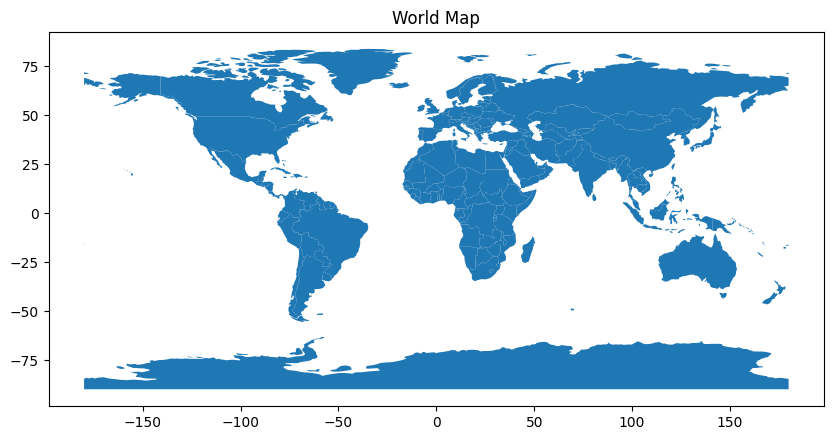

In [61]:
gdf.plot(figsize=(10, 6))
plt.title("World Map")
plt.show()

## Merge Population Data with Map

We need to:

1. select a specific year  
2. merge population data with map data  

---

## Select a year

In [63]:
year = 2023

population_year = population_df[population_df["year"] == year]
population_year.head()

,country,country_code,year,population,continent
73,Afghanistan,AFG,2023,41454762,Asia
295,Albania,ALB,2023,2811660,Europe
369,Algeria,DZA,2023,46164222,Africa
443,American Samoa,ASM,2023,47544,Oceania
591,Andorra,AND,2023,80869,Europe


## Merge datasets

In the `gdf` GeoDataFrame, we have both the geometry of each country and its population for the selected year. We merge based on the `adm0_a3` country code, which is a common identifier for countries in geographic datasets, which also exists in the OWID population dataset as `country_code`. This allows us to combine the population data with the geographic data for each country.

In [64]:
merged = gdf[['admin', 'adm0_a3', 'geometry']].merge(
    population_year,
    left_on="adm0_a3",
    right_on="country_code",
    how="left"
)

merged.head()

,admin,adm0_a3,geometry,country,country_code,year,population,continent
0,Afghanistan,AFG,"POLYGON ((61.21082 35.65007, 62.23065 35.27066...",Afghanistan,AFG,2023.0,41454762.0,Asia
1,Angola,AGO,"MULTIPOLYGON (((16.32653 -5.87747, 16.57318 -6...",Angola,AGO,2023.0,36749909.0,Africa
2,Albania,ALB,"POLYGON ((20.59025 41.8554, 20.46318 41.51509,...",Albania,ALB,2023.0,2811660.0,Europe
3,United Arab Emirates,ARE,"POLYGON ((51.57952 24.2455, 51.75744 24.29407,...",United Arab Emirates,ARE,2023.0,10642089.0,Asia
4,Argentina,ARG,"MULTIPOLYGON (((-65.5 -55.2, -66.45 -55.25, -6...",Argentina,ARG,2023.0,45538402.0,South America


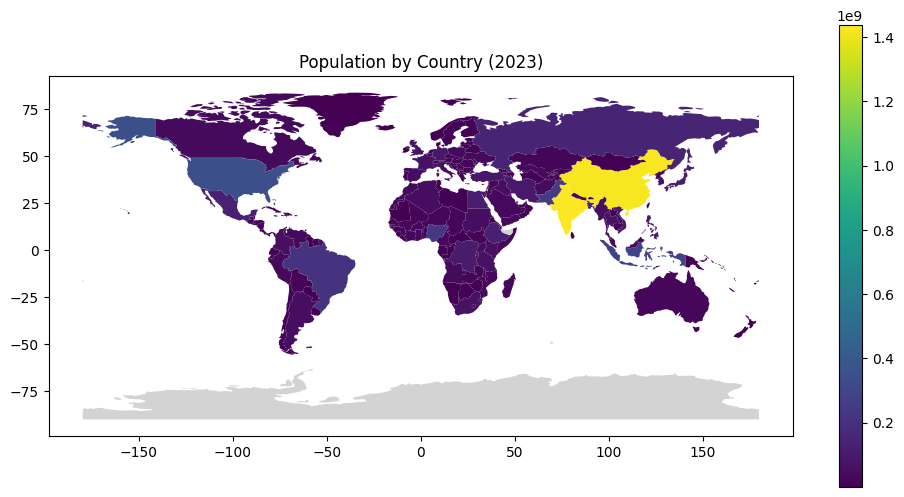

In [66]:
import numpy as np

merged.plot(
    column="population",
    cmap="viridis",
    legend=True,
    figsize=(12, 6),
    missing_kwds={"color": "lightgrey"}
)

plt.title(f"Population by Country ({year})")
plt.show()

### Improve Readability

Population values vary widely, making visualization difficult.

We can use a logarithmic transformation.

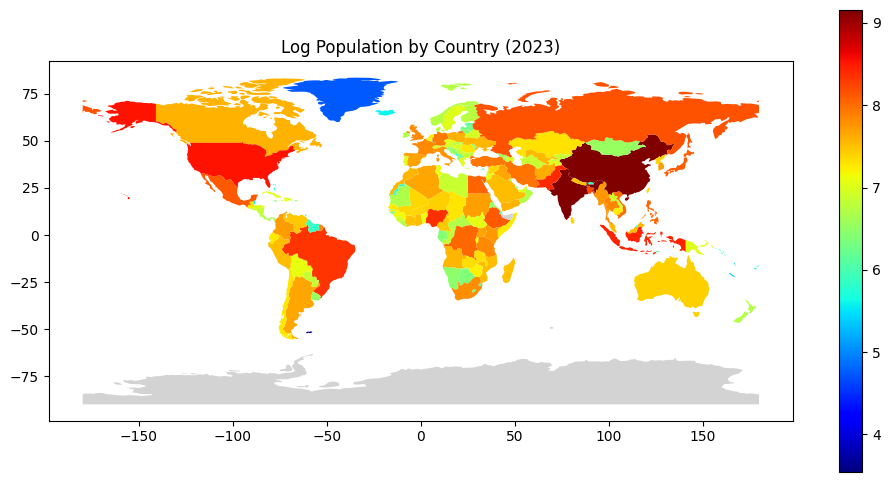

In [68]:
import numpy as np

merged["log_population"] = np.log10(merged["population"])

merged.plot(
    column="log_population",
    cmap="jet",
    legend=True,
    figsize=(12, 6),
    missing_kwds={"color": "lightgrey"}
)

plt.title(f"Log Population by Country ({year})")
plt.show()

## Interactive Map with `.explore()`

GeoPandas also supports interactive maps.


In [69]:
merged.explore(
    column="log_population",
    cmap="viridis",
    missing_kwds={"color": "lightgrey"})

We will now:

- turn this process into a reusable function  
- apply it to other datasets (GDP, life expectancy)  